In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import catboost as cgb
except:
    !uv pip install catboost
    import catboost as cgb

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


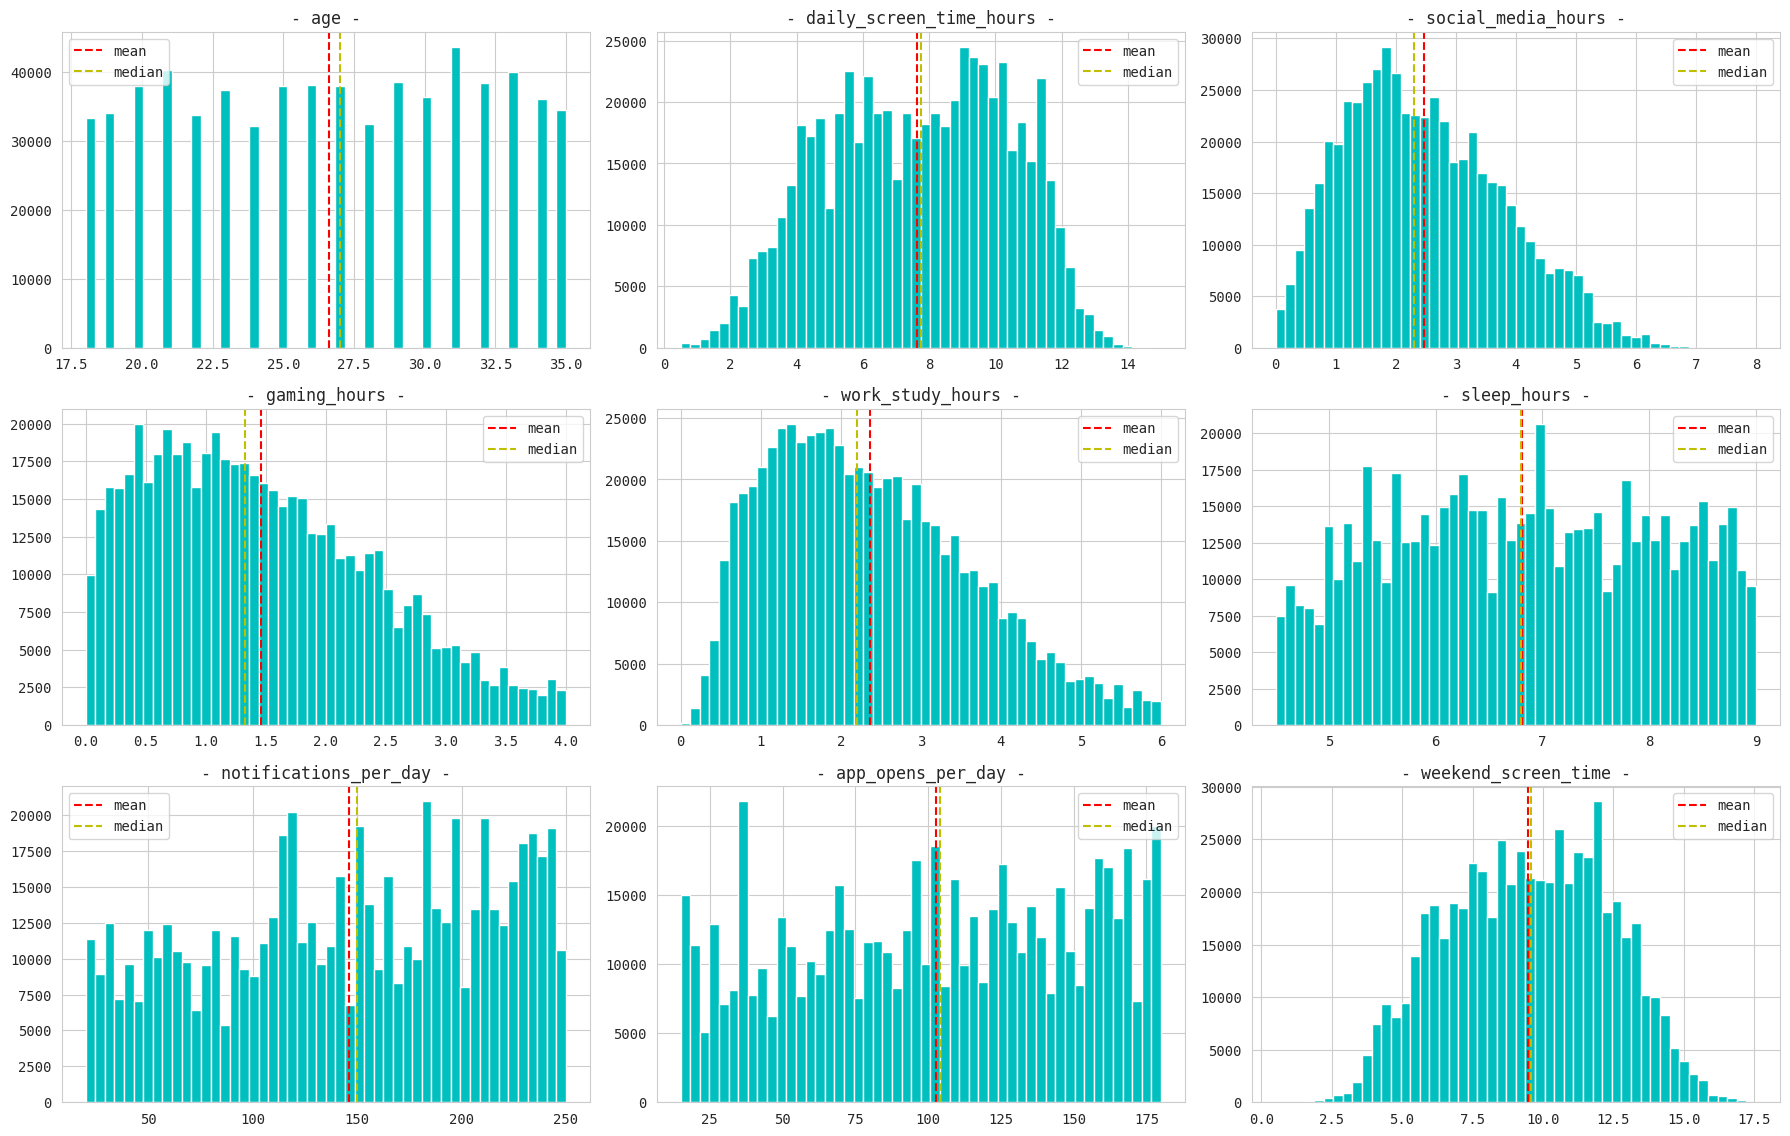

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Test
age,18,18
daily_screen_time_hours,1389,1349
social_media_hours,721,703
gaming_hours,401,401
work_study_hours,600,601
sleep_hours,451,451
notifications_per_day,231,231
app_opens_per_day,166,166
weekend_screen_time,1437,1404
gender,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
for col in NUMS:
    # print(f"\nRounding... ", end='')
    # for r in range(-2, 3):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')

    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in range(-3, 3):
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


DIGITS... age_digit_-3, age_digit_-2, age_digit_-1, age_digit_0, age_digit_1, age_digit_2, 
DIGITS... daily_screen_time_hours_digit_-3, daily_screen_time_hours_digit_-2, daily_screen_time_hours_digit_-1, daily_screen_time_hours_digit_0, daily_screen_time_hours_digit_1, daily_screen_time_hours_digit_2, 
DIGITS... social_media_hours_digit_-3, social_media_hours_digit_-2, social_media_hours_digit_-1, social_media_hours_digit_0, social_media_hours_digit_1, social_media_hours_digit_2, 
DIGITS... gaming_hours_digit_-3, gaming_hours_digit_-2, gaming_hours_digit_-1, gaming_hours_digit_0, gaming_hours_digit_1, gaming_hours_digit_2, 
DIGITS... work_study_hours_digit_-3, work_study_hours_digit_-2, work_study_hours_digit_-1, work_study_hours_digit_0, work_study_hours_digit_1, work_study_hours_digit_2, 
DIGITS... sleep_hours_digit_-3, sleep_hours_digit_-2, sleep_hours_digit_-1, sleep_hours_digit_0, sleep_hours_digit_1, sleep_hours_digit_2, 
DIGITS... notifications_per_day_digit_-3, notifications_p

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

age_digit_-3                         2
age_digit_-2                         2
age_digit_-1                         4
age_digit_0                         11
age_digit_1                          2
age_digit_2                          2
daily_screen_time_hours_digit_-3     2
daily_screen_time_hours_digit_-2     2
daily_screen_time_hours_digit_-1     3
daily_screen_time_hours_digit_0     11
daily_screen_time_hours_digit_1     11
daily_screen_time_hours_digit_2     11
social_media_hours_digit_-3          2
social_media_hours_digit_-2          2
social_media_hours_digit_-1          2
social_media_hours_digit_0          10
social_media_hours_digit_1          11
social_media_hours_digit_2          11
gaming_hours_digit_-3                2
gaming_hours_digit_-2                2
gaming_hours_digit_-1                2
gaming_hours_digit_0                 6
gaming_hours_digit_1                11
gaming_hours_digit_2                11
work_study_hours_digit_-3            2
work_study_hours_digit_-2

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
## -- Frequency encoding --
FREQ_COLS = []

print(f"\nCreating frequencies... ", end='')
for col in NUMS: # 'Position_Change'
    freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test]: # , orig
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    FREQ_COLS.append(n)

print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
train[FREQ_COLS]


Creating frequencies... age_freq, daily_screen_time_hours_freq, social_media_hours_freq, gaming_hours_freq, work_study_hours_freq, sleep_hours_freq, notifications_per_day_freq, app_opens_per_day_freq, weekend_screen_time_freq, 
✓ Total frequency features: 9


,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq
0,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754
1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000
2,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919
3,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735
4,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638
...,...,...,...,...,...,...,...,...,...
691364,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169
691365,0.057368,0.001341,0.004068,0.002797,0.000549,0.004163,0.005939,0.011147,0.003234
691366,0.000000,0.000000,0.000000,0.000000,0.003335,0.001894,0.000000,0.002395,0.001529
691367,0.051199,0.001638,0.002188,0.002592,0.004219,0.001178,0.003195,0.003110,0.002057


In [17]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [18]:
# ## -- Arithmetic interactions --
# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [19]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [22]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# train

In [23]:
## -- Duplicate all numerics as categories --
CATS_2 = []

for c in NUMS:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    # orig[n]  = orig[c].copy()
    CATS_2.append(n)

    ## -- Factorize -- 
    combined  = pd.concat([train[n], test[n]]) # , orig[n]
    cat_v = combined.factorize()[0]
    # cat_v = pd.Series(cat_v).astype('category')
    train[n] = cat_v[:len(train)].astype('int32')
    test[n]  = cat_v[len(train):len(train)+len(test)].astype('int32')
    # orig[n]  = __[len(train)+len(test):].astype('int32')

del combined, cat_v
print(f"Nums to Cats: {len(CATS_2)}")

CATS_2

Nums to Cats: 9


['cat_age',
 'cat_daily_screen_time_hours',
 'cat_social_media_hours',
 'cat_gaming_hours',
 'cat_work_study_hours',
 'cat_sleep_hours',
 'cat_notifications_per_day',
 'cat_app_opens_per_day',
 'cat_weekend_screen_time']

In [24]:
## -- Factorize combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    cat_v = combined.factorize()[0]
    # cat_v = pd.Series(cat_v).astype('category')
    train[c] = cat_v[:len(train)]
    test[c]  = cat_v[len(train):len(train)+len(test)]
    orig[c]  = cat_v[len(train)+len(test):]

del combined, cat_v
print("Label encoding complete!")

Label encoding complete!


In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 84


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_digit_-3,age_digit_-2,age_digit_-1,age_digit_0,age_digit_1,age_digit_2,daily_screen_time_hours_digit_-3,daily_screen_time_hours_digit_-2,daily_screen_time_hours_digit_-1,daily_screen_time_hours_digit_0,daily_screen_time_hours_digit_1,daily_screen_time_hours_digit_2,social_media_hours_digit_-3,social_media_hours_digit_-2,social_media_hours_digit_-1,social_media_hours_digit_0,social_media_hours_digit_1,social_media_hours_digit_2,gaming_hours_digit_-3,gaming_hours_digit_-2,gaming_hours_digit_-1,gaming_hours_digit_0,gaming_hours_digit_1,gaming_hours_digit_2,work_study_hours_digit_-3,work_study_hours_digit_-2,work_study_hours_digit_-1,work_study_hours_digit_0,work_study_hours_digit_1,work_study_hours_digit_2,sleep_hours_digit_-3,sleep_hours_digit_-2,sleep_hours_digit_-1,sleep_hours_digit_0,sleep_hours_digit_1,sleep_hours_digit_2,notifications_per_day_digit_-3,notifications_per_day_digit_-2,notifications_per_day_digit_-1,notifications_per_day_digit_0,notifications_per_day_digit_1,notifications_per_day_digit_2,app_opens_per_day_digit_-3,app_opens_per_day_digit_-2,app_opens_per_day_digit_-1,app_opens_per_day_digit_0,app_opens_per_day_digit_1,app_opens_per_day_digit_2,weekend_screen_time_digit_-3,weekend_screen_time_digit_-2,weekend_screen_time_digit_-1,weekend_screen_time_digit_0,weekend_screen_time_digit_1,weekend_screen_time_digit_2,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1,0,0,2,4,0,0,-1,-1,-1,-1,-1,-1,0,0,0,1,8,3,0,0,0,1,5,9,0,0,0,2,1,1,0,0,0,7,4,6,0,1,2,2,0,0,0,0,3,8,0,0,0,0,0,8,6,3,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754,0,-1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0,0,0,1,9,0,0,0,0,0,5,9,7,0,0,0,1,0,8,-1,-1,-1,-1,-1,-1,0,0,0,3,0,3,0,0,0,8,2,2,0,0,7,6,0,0,0,0,1,9,0,0,-1,-1,-1,-1,-1,-1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000,1,0,1,-1,1,1,1,1,-1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0,0,0,1,8,0,0,0,0,0,5,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,0,6,2,5,0,1,3,4,0,0,0,0,6,0,0,0,0,0,0,7,4,7,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919,2,1,-1,-1,-1,2,2,2,1
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1,0,0,2,1,0,0,0,0,0,6,4,2,0,0,0,1,2,6,0,0,0,1,4,2,0,0,0,3,3,6,0,0,0,8,8,5,0,1,1,2,0,0,0,0,9,4,0,0,0,0,0,8,6,6,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735,3,2,2,1,2,3,3,3,2
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1,0,0,2,6,0,0,0,0,1,1,2,0,0,0,0,1,8,7,0,0,0,2,8,1,0,0,0,1,9,5,0,0,0,5,2,5,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,1,3,3,9,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638,4,3,3,2,3,4,-1,-1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1,0,0,2,2,0,0,0,0,1,0,7,8,0,0,0,3,2,5,0,0,0,1,5,7,0,0,0,1,6,5,0,0,0,7,7,1,0,0,8,6,0,0,0,0,9,4,0,0,0,0,1,2,8,9,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169,12,783,374,145,109,88,168,3,786
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,22

# ML TRAINING

In [26]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols,
               use_orig=False, early_stop=100, print_every=200):
    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits}", end=" | ")

        ## -- Split data for the current fold
        X_train, X_valid = X.loc[train_idx], X.loc[val_idx]
        y_train, y_valid = y.loc[train_idx], y.loc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
                fill_nan=True,
            )

        ## -- TE Opt1. -> Using CUSTOM -- 
        te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)

        all_categorical = cat_cols.copy()
        combined = pd.concat([X_train, X_valid, X_test])

        for c in all_categorical:
            combined[c] = combined[c].astype(str)

        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=10_000,
            eval_set=dval,
            early_stopping_rounds=early_stop,
            verbose=print_every,
        )

        feat_importances.append(model.get_feature_importance(prettified=True))

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1].ravel()
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1].ravel() / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del dtrain, dval, dtest
        # gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {score:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [27]:
VER = "cat_TE(84)_"
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS # + CATS_2

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_digit_-3,age_digit_-2,age_digit_-1,age_digit_0,age_digit_1,age_digit_2,daily_screen_time_hours_digit_-3,daily_screen_time_hours_digit_-2,daily_screen_time_hours_digit_-1,daily_screen_time_hours_digit_0,daily_screen_time_hours_digit_1,daily_screen_time_hours_digit_2,social_media_hours_digit_-3,social_media_hours_digit_-2,social_media_hours_digit_-1,social_media_hours_digit_0,social_media_hours_digit_1,social_media_hours_digit_2,gaming_hours_digit_-3,gaming_hours_digit_-2,gaming_hours_digit_-1,gaming_hours_digit_0,gaming_hours_digit_1,gaming_hours_digit_2,work_study_hours_digit_-3,work_study_hours_digit_-2,work_study_hours_digit_-1,work_study_hours_digit_0,work_study_hours_digit_1,work_study_hours_digit_2,sleep_hours_digit_-3,sleep_hours_digit_-2,sleep_hours_digit_-1,sleep_hours_digit_0,sleep_hours_digit_1,sleep_hours_digit_2,notifications_per_day_digit_-3,notifications_per_day_digit_-2,notifications_per_day_digit_-1,notifications_per_day_digit_0,notifications_per_day_digit_1,notifications_per_day_digit_2,app_opens_per_day_digit_-3,app_opens_per_day_digit_-2,app_opens_per_day_digit_-1,app_opens_per_day_digit_0,app_opens_per_day_digit_1,app_opens_per_day_digit_2,weekend_screen_time_digit_-3,weekend_screen_time_digit_-2,weekend_screen_time_digit_-1,weekend_screen_time_digit_0,weekend_screen_time_digit_1,weekend_screen_time_digit_2,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1,0,0,2,4,0,0,-1,-1,-1,-1,-1,-1,0,0,0,1,8,3,0,0,0,1,5,9,0,0,0,2,1,1,0,0,0,7,4,6,0,1,2,2,0,0,0,0,3,8,0,0,0,0,0,8,6,3,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754,0,-1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0,0,0,1,9,0,0,0,0,0,5,9,7,0,0,0,1,0,8,-1,-1,-1,-1,-1,-1,0,0,0,3,0,3,0,0,0,8,2,2,0,0,7,6,0,0,0,0,1,9,0,0,-1,-1,-1,-1,-1,-1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000,1,0,1,-1,1,1,1,1,-1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0,0,0,1,8,0,0,0,0,0,5,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,0,6,2,5,0,1,3,4,0,0,0,0,6,0,0,0,0,0,0,7,4,7,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919,2,1,-1,-1,-1,2,2,2,1
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1,0,0,2,1,0,0,0,0,0,6,4,2,0,0,0,1,2,6,0,0,0,1,4,2,0,0,0,3,3,6,0,0,0,8,8,5,0,1,1,2,0,0,0,0,9,4,0,0,0,0,0,8,6,6,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735,3,2,2,1,2,3,3,3,2
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1,0,0,2,6,0,0,0,0,1,1,2,0,0,0,0,1,8,7,0,0,0,2,8,1,0,0,0,1,9,5,0,0,0,5,2,5,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,1,3,3,9,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638,4,3,3,2,3,4,-1,-1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1,0,0,2,2,0,0,0,0,1,0,7,8,0,0,0,3,2,5,0,0,0,1,5,7,0,0,0,1,6,5,0,0,0,7,7,1,0,0,8,6,0,0,0,0,9,4,0,0,0,0,1,2,8,9,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169,12,783,374,145,109,88,168,3,786
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,22

In [28]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# OUT_LOOP = [0.5, 1.0]
# INN_LOOP = [4.0]
# p_name   = ['BT', 'L1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': outer,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.05,
#             # 'depth': 6,
#             # 'l2_leaf_reg': REGULATE,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [29]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('CATBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score-5e-8, score, ha='right', va='baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

In [30]:
LR = 0.03
# L2_REG = 2.5
EARLY_STOP   = 100
PRINT_STEPS  = 1000
USE_ORIGINAL = False

In [31]:
## ========================== BAYESIAN 
bayes_params = {
    'boosting_type': 'Plain',
    'grow_policy': 'SymmetricTree',
    'bootstrap_type': 'Bayesian',
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bayes_params,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_TE(84)_bayes =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9295461	best: 0.9295461 (0)	total: 170ms	remaining: 28m 18s
1000:	test: 0.9649196	best: 0.9649196 (1000)	total: 32.9s	remaining: 4m 55s
2000:	test: 0.9660425	best: 0.9660427 (1999)	total: 1m 5s	remaining: 4m 22s
3000:	test: 0.9663944	best: 0.9663944 (3000)	total: 1m 38s	remaining: 3m 50s
4000:	test: 0.9665439	best: 0.9665440 (3996)	total: 2m 11s	remaining: 3m 17s
5000:	test: 0.9666152	best: 0.9666172 (4941)	total: 2m 44s	remaining: 2m 44s
bestTest = 0.9666363597
bestIteration = 5520
Shrink model to first 5521 iterations.
 • Fold 1 AUC: 0.966636

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9312698	best: 0.9312698 (0)	total: 51.8ms	remaining: 8m 38s
1000:	test: 0.9656693	best: 0.9656693 (1000)	total: 33.3s	remaining: 4m 59s
2000:	test: 0.9668021	best: 0.9668021 (2000)	total: 1m 6s	remaining: 4m 26s
3000:	test: 0.9671187	best: 0.9671187 (3000)	total: 1m 39s	remaining: 3m 52s
4000:	test: 0.9672727	best: 0.9672735 (3995)	total: 2m 12s	remaining: 3m 19s
5000:	test: 0.9673569	best: 0.9673579 (4993)	total: 2m 45s	remaining: 2m 45s
bestTest = 0.9673613906
bestIteration = 5128
Shrink model to first 5129 iterations.
 • Fold 2 AUC: 0.967361

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9322017	best: 0.9322017 (0)	total: 48.9ms	remaining: 8m 8s
1000:	test: 0.9659690	best: 0.9659693 (999)	total: 33.2s	remaining: 4m 58s
2000:	test: 0.9670108	best: 0.9670108 (2000)	total: 1m 6s	remaining: 4m 24s
3000:	test: 0.9673327	best: 0.9673328 (2995)	total: 1m 39s	remaining: 3m 50s
4000:	test: 0.9675061	best: 0.9675072 (3982)	total: 2m 11s	remaining: 3m 17s
5000:	test: 0.9675893	best: 0.9675905 (4953)	total: 2m 44s	remaining: 2m 44s
bestTest = 0.9675904512
bestIteration = 4953
Shrink model to first 4954 iterations.
 • Fold 3 AUC: 0.967591

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9315553	best: 0.9315553 (0)	total: 48.6ms	remaining: 8m 5s
1000:	test: 0.9661681	best: 0.9661681 (1000)	total: 33.1s	remaining: 4m 58s
2000:	test: 0.9672961	best: 0.9672970 (1998)	total: 1m 6s	remaining: 4m 24s
3000:	test: 0.9676588	best: 0.9676598 (2995)	total: 1m 39s	remaining: 3m 51s
4000:	test: 0.9678366	best: 0.9678368 (3999)	total: 2m 11s	remaining: 3m 17s
5000:	test: 0.9679096	best: 0.9679111 (4982)	total: 2m 44s	remaining: 2m 44s
bestTest = 0.9679356813
bestIteration = 5408
Shrink model to first 5409 iterations.
 • Fold 4 AUC: 0.967936

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9305690	best: 0.9305690 (0)	total: 48.6ms	remaining: 8m 5s
1000:	test: 0.9651246	best: 0.9651246 (1000)	total: 33s	remaining: 4m 56s
2000:	test: 0.9663321	best: 0.9663322 (1999)	total: 1m 5s	remaining: 4m 23s
3000:	test: 0.9666962	best: 0.9666962 (3000)	total: 1m 38s	remaining: 3m 50s
4000:	test: 0.9668908	best: 0.9668913 (3974)	total: 2m 11s	remaining: 3m 16s
bestTest = 0.9669340551
bestIteration = 4577
Shrink model to first 4578 iterations.
 • Fold 5 AUC: 0.966934

5-FOLD CV: cat_TE(84)_bayes
 • Fold 1 AUC: 0.966636
 • Fold 2 AUC: 0.967361
 • Fold 3 AUC: 0.967591
 • Fold 4 AUC: 0.967936
 • Fold 5 AUC: 0.966934
-------------------------------------------------|
Overall AUC: 0.967292
Average AUC: 0.967292 ± 0.000462
-------------------------------------------------|
15.06 mins



In [32]:
# ==================================================
# 5-FOLD CV: cat_TE_bayes
# ==================================================
#  • Fold 1 AUC: 0.966638
#  • Fold 2 AUC: 0.967381
#  • Fold 3 AUC: 0.967625
#  • Fold 4 AUC: 0.967941
#  • Fold 5 AUC: 0.967004
# -------------------------------------------------|
# Overall AUC: 0.967317
# Average AUC: 0.967318 ± 0.000458
# -------------------------------------------------|
# 17.24 mins

In [33]:
# ## =========================== MVS -- OOM issues
# mvs_params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     # 'learning_rate': LR,
#     # ---------------------------------
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     # 'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     # 'depth': 6,
#     # 'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'thread_count': -1,
#     'allow_writing_files': False,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = VER+"cat_mvs"

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=mvs_params,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     use_orig=USE_ORIGINAL,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
# )

In [34]:
## =========================== BERNOULLI
bern_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Plain",
    'grow_policy': "Depthwise",
    'bootstrap_type': "Bernoulli",
    # ---------------------------------
    # 'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.7,
    'min_data_in_leaf': 40,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "bern"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bern_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS
)


===== Starting CV: cat_TE(84)_bern =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9379930	best: 0.9379930 (0)	total: 120ms	remaining: 19m 59s
1000:	test: 0.9651961	best: 0.9651961 (1000)	total: 24.8s	remaining: 3m 42s
2000:	test: 0.9659600	best: 0.9659600 (2000)	total: 49.7s	remaining: 3m 18s
3000:	test: 0.9661255	best: 0.9661255 (3000)	total: 1m 14s	remaining: 2m 54s
bestTest = 0.966142863
bestIteration = 3160
Shrink model to first 3161 iterations.
 • Fold 1 AUC: 0.966143

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9380579	best: 0.9380579 (0)	total: 41.3ms	remaining: 6m 53s
1000:	test: 0.9658881	best: 0.9658881 (1000)	total: 24.7s	remaining: 3m 41s
2000:	test: 0.9666739	best: 0.9666739 (2000)	total: 49.3s	remaining: 3m 17s
3000:	test: 0.9668578	best: 0.9668615 (2919)	total: 1m 14s	remaining: 2m 53s
bestTest = 0.966861546
bestIteration = 2919
Shrink model to first 2920 iterations.
 • Fold 2 AUC: 0.966862

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9395925	best: 0.9395925 (0)	total: 43.1ms	remaining: 7m 11s
1000:	test: 0.9663914	best: 0.9663914 (1000)	total: 25s	remaining: 3m 44s
2000:	test: 0.9670820	best: 0.9670820 (2000)	total: 49.2s	remaining: 3m 16s
bestTest = 0.9672558904
bestIteration = 2871
Shrink model to first 2872 iterations.
 • Fold 3 AUC: 0.967256

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9395810	best: 0.9395810 (0)	total: 44ms	remaining: 7m 19s
1000:	test: 0.9665995	best: 0.9665995 (1000)	total: 24.5s	remaining: 3m 40s
2000:	test: 0.9673388	best: 0.9673388 (2000)	total: 49s	remaining: 3m 16s
3000:	test: 0.9674951	best: 0.9674971 (2989)	total: 1m 14s	remaining: 2m 52s
bestTest = 0.9675366282
bestIteration = 3369
Shrink model to first 3370 iterations.
 • Fold 4 AUC: 0.967537

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9383830	best: 0.9383830 (0)	total: 42ms	remaining: 6m 59s
1000:	test: 0.9655530	best: 0.9655530 (1000)	total: 25s	remaining: 3m 45s
2000:	test: 0.9663360	best: 0.9663360 (2000)	total: 49.2s	remaining: 3m 16s
3000:	test: 0.9665421	best: 0.9665436 (2948)	total: 1m 13s	remaining: 2m 51s
bestTest = 0.9665739536
bestIteration = 3341
Shrink model to first 3342 iterations.
 • Fold 5 AUC: 0.966574

5-FOLD CV: cat_TE(84)_bern
 • Fold 1 AUC: 0.966143
 • Fold 2 AUC: 0.966862
 • Fold 3 AUC: 0.967256
 • Fold 4 AUC: 0.967537
 • Fold 5 AUC: 0.966574
-------------------------------------------------|
Overall AUC: 0.966873
Average AUC: 0.966874 ± 0.000492
-------------------------------------------------|
8.26 mins



In [35]:
# ==================================================
# 5-FOLD CV: cat_TE_bern
# ==================================================
#  • Fold 1 AUC: 0.966163
#  • Fold 2 AUC: 0.966866
#  • Fold 3 AUC: 0.967248
#  • Fold 4 AUC: 0.967543
#  • Fold 5 AUC: 0.966586
# -------------------------------------------------|
# Overall AUC: 0.96688
# Average AUC: 0.966881 ± 0.000485
# -------------------------------------------------|
# 8.91 mins

In [36]:
## =========================== LOSSGUIDE

loss_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 6,
    # ---------------------------------
    'boosting_type': 'Plain',
    'grow_policy': 'Lossguide',
    # ---------------------------------
    # 'max_leaves': 32,
    'min_data_in_leaf': 2,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "loss"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_TE(84)_loss =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9292784	best: 0.9292784 (0)	total: 49.6ms	remaining: 8m 15s
1000:	test: 0.9650796	best: 0.9650796 (1000)	total: 34.9s	remaining: 5m 13s
2000:	test: 0.9658255	best: 0.9658255 (2000)	total: 1m 9s	remaining: 4m 39s
3000:	test: 0.9660736	best: 0.9660736 (3000)	total: 1m 47s	remaining: 4m 11s
4000:	test: 0.9661843	best: 0.9661847 (3997)	total: 2m 22s	remaining: 3m 33s
5000:	test: 0.9662363	best: 0.9662371 (4955)	total: 2m 58s	remaining: 2m 58s
bestTest = 0.9662371278
bestIteration = 4955
Shrink model to first 4956 iterations.
 • Fold 1 AUC: 0.966237

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9293125	best: 0.9293125 (0)	total: 53.3ms	remaining: 8m 52s
1000:	test: 0.9659337	best: 0.9659337 (1000)	total: 36.5s	remaining: 5m 28s
2000:	test: 0.9666476	best: 0.9666477 (1993)	total: 1m 13s	remaining: 4m 52s
3000:	test: 0.9669186	best: 0.9669188 (2999)	total: 1m 49s	remaining: 4m 15s
4000:	test: 0.9670209	best: 0.9670225 (3965)	total: 2m 27s	remaining: 3m 41s
5000:	test: 0.9670809	best: 0.9670809 (5000)	total: 3m	remaining: 3m
bestTest = 0.9671007991
bestIteration = 5245
Shrink model to first 5246 iterations.
 • Fold 2 AUC: 0.967101

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9311579	best: 0.9311579 (0)	total: 51.8ms	remaining: 8m 38s
1000:	test: 0.9663071	best: 0.9663072 (999)	total: 36.7s	remaining: 5m 29s
2000:	test: 0.9669808	best: 0.9669811 (1998)	total: 1m 13s	remaining: 4m 52s
3000:	test: 0.9672085	best: 0.9672093 (2999)	total: 1m 48s	remaining: 4m 13s
bestTest = 0.9672970772
bestIteration = 3679
Shrink model to first 3680 iterations.
 • Fold 3 AUC: 0.967297

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9310872	best: 0.9310872 (0)	total: 47.3ms	remaining: 7m 53s
1000:	test: 0.9663994	best: 0.9663994 (1000)	total: 36.3s	remaining: 5m 26s
2000:	test: 0.9671544	best: 0.9671544 (2000)	total: 1m 11s	remaining: 4m 47s
3000:	test: 0.9673935	best: 0.9673955 (2996)	total: 1m 49s	remaining: 4m 14s
4000:	test: 0.9675170	best: 0.9675174 (3994)	total: 2m 24s	remaining: 3m 36s
5000:	test: 0.9675799	best: 0.9675799 (5000)	total: 2m 58s	remaining: 2m 58s
6000:	test: 0.9676389	best: 0.9676396 (5997)	total: 3m 33s	remaining: 2m 22s
bestTest = 0.9676458836
bestIteration = 6119
Shrink model to first 6120 iterations.
 • Fold 4 AUC: 0.967646

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9301448	best: 0.9301448 (0)	total: 50.4ms	remaining: 8m 23s
1000:	test: 0.9653749	best: 0.9653758 (999)	total: 36.7s	remaining: 5m 29s
2000:	test: 0.9661322	best: 0.9661322 (2000)	total: 1m 11s	remaining: 4m 44s
3000:	test: 0.9664265	best: 0.9664277 (2992)	total: 1m 46s	remaining: 4m 8s
4000:	test: 0.9665378	best: 0.9665415 (3973)	total: 2m 20s	remaining: 3m 31s
bestTest = 0.9665666819
bestIteration = 4258
Shrink model to first 4259 iterations.
 • Fold 5 AUC: 0.966567

5-FOLD CV: cat_TE(84)_loss
 • Fold 1 AUC: 0.966237
 • Fold 2 AUC: 0.967101
 • Fold 3 AUC: 0.967297
 • Fold 4 AUC: 0.967646
 • Fold 5 AUC: 0.966567
-------------------------------------------------|
Overall AUC: 0.966969
Average AUC: 0.966970 ± 0.000506
-------------------------------------------------|
16.84 mins



In [37]:
# ==================================================
# 5-FOLD CV: cat_TE_loss
# ==================================================
#  • Fold 1 AUC: 0.966239
#  • Fold 2 AUC: 0.967102
#  • Fold 3 AUC: 0.967352
#  • Fold 4 AUC: 0.967591
#  • Fold 5 AUC: 0.966620
# -------------------------------------------------|
# Overall AUC: 0.966981
# Average AUC: 0.966981 ± 0.000491
# -------------------------------------------------|
# 16.69 mins

In [38]:
## =========================== ORDERED 

ord_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Ordered",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "ord_bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ord_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_TE(84)_ord_bayes =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9296591	best: 0.9296591 (0)	total: 147ms	remaining: 24m 28s
1000:	test: 0.9652179	best: 0.9652179 (1000)	total: 1m 20s	remaining: 12m 6s
2000:	test: 0.9660431	best: 0.9660431 (2000)	total: 2m 36s	remaining: 10m 24s
3000:	test: 0.9662976	best: 0.9662976 (2999)	total: 3m 42s	remaining: 8m 39s
4000:	test: 0.9664437	best: 0.9664441 (3994)	total: 4m 51s	remaining: 7m 16s
5000:	test: 0.9665558	best: 0.9665558 (4992)	total: 5m 54s	remaining: 5m 54s
6000:	test: 0.9666274	best: 0.9666274 (6000)	total: 6m 59s	remaining: 4m 39s
7000:	test: 0.9666657	best: 0.9666657 (6999)	total: 8m 2s	remaining: 3m 26s
8000:	test: 0.9667054	best: 0.9667059 (7995)	total: 9m 5s	remaining: 2m 16s
bestTest = 0.9667224288
bestIteration = 8635
Shrink model to first 8636 iterations.
 • Fold 1 AUC: 0.966722

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9313016	best: 0.9313016 (0)	total: 146ms	remaining: 24m 21s
1000:	test: 0.9658019	best: 0.9658019 (1000)	total: 1m 20s	remaining: 12m 7s
2000:	test: 0.9668358	best: 0.9668358 (2000)	total: 2m 37s	remaining: 10m 29s
3000:	test: 0.9670861	best: 0.9670864 (2996)	total: 3m 41s	remaining: 8m 37s
4000:	test: 0.9671888	best: 0.9671888 (4000)	total: 4m 39s	remaining: 6m 59s
5000:	test: 0.9672693	best: 0.9672697 (4976)	total: 5m 42s	remaining: 5m 42s
6000:	test: 0.9673260	best: 0.9673265 (5991)	total: 6m 44s	remaining: 4m 29s
bestTest = 0.9673543572
bestIteration = 6725
Shrink model to first 6726 iterations.
 • Fold 2 AUC: 0.967354

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9322017	best: 0.9322017 (0)	total: 145ms	remaining: 24m 8s
1000:	test: 0.9661742	best: 0.9661742 (1000)	total: 1m 20s	remaining: 12m 5s
2000:	test: 0.9671115	best: 0.9671115 (2000)	total: 2m 36s	remaining: 10m 24s
3000:	test: 0.9673489	best: 0.9673490 (2999)	total: 3m 46s	remaining: 8m 47s
4000:	test: 0.9674641	best: 0.9674641 (4000)	total: 4m 53s	remaining: 7m 20s
5000:	test: 0.9676213	best: 0.9676213 (5000)	total: 6m 9s	remaining: 6m 9s
6000:	test: 0.9677058	best: 0.9677075 (5971)	total: 7m 20s	remaining: 4m 53s
7000:	test: 0.9677497	best: 0.9677497 (6984)	total: 8m 31s	remaining: 3m 39s
bestTest = 0.9677631855
bestIteration = 7659
Shrink model to first 7660 iterations.
 • Fold 3 AUC: 0.967763

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9316226	best: 0.9316226 (0)	total: 145ms	remaining: 24m 12s
1000:	test: 0.9663923	best: 0.9663923 (1000)	total: 1m 20s	remaining: 12m 3s
2000:	test: 0.9672982	best: 0.9672982 (2000)	total: 2m 39s	remaining: 10m 37s
3000:	test: 0.9675822	best: 0.9675822 (3000)	total: 3m 54s	remaining: 9m 7s
4000:	test: 0.9676802	best: 0.9676813 (3994)	total: 5m 8s	remaining: 7m 42s
5000:	test: 0.9678032	best: 0.9678032 (4992)	total: 6m 18s	remaining: 6m 18s
6000:	test: 0.9678772	best: 0.9678772 (5998)	total: 7m 24s	remaining: 4m 56s
7000:	test: 0.9679412	best: 0.9679412 (7000)	total: 8m 30s	remaining: 3m 38s
bestTest = 0.9679766297
bestIteration = 7593
Shrink model to first 7594 iterations.
 • Fold 4 AUC: 0.967977

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9305690	best: 0.9305690 (0)	total: 145ms	remaining: 24m 8s
1000:	test: 0.9652644	best: 0.9652644 (1000)	total: 1m 20s	remaining: 12m 2s
2000:	test: 0.9661094	best: 0.9661094 (1999)	total: 2m 28s	remaining: 9m 52s
3000:	test: 0.9663470	best: 0.9663472 (2988)	total: 3m 32s	remaining: 8m 15s
4000:	test: 0.9664511	best: 0.9664511 (3966)	total: 4m 27s	remaining: 6m 41s
5000:	test: 0.9665525	best: 0.9665525 (5000)	total: 5m 20s	remaining: 5m 20s
bestTest = 0.9665800929
bestIteration = 5639
Shrink model to first 5640 iterations.
 • Fold 5 AUC: 0.966580

5-FOLD CV: cat_TE(84)_ord_bayes
 • Fold 1 AUC: 0.966722
 • Fold 2 AUC: 0.967354
 • Fold 3 AUC: 0.967763
 • Fold 4 AUC: 0.967977
 • Fold 5 AUC: 0.966580
-------------------------------------------------|
Overall AUC: 0.96728
Average AUC: 0.967279 ± 0.000552
-------------------------------------------------|
42.77 mins



In [39]:
# ==================================================
# 5-FOLD CV: cat_TE_ordered_bayes
# ==================================================
#  • Fold 1 AUC: 0.966628
#  • Fold 2 AUC: 0.967291
#  • Fold 3 AUC: 0.967751
#  • Fold 4 AUC: 0.967914
#  • Fold 5 AUC: 0.966325
# -------------------------------------------------|
# Overall AUC: 0.967183
# Average AUC: 0.967182 ± 0.000618
# -------------------------------------------------|
# 37.20 mins

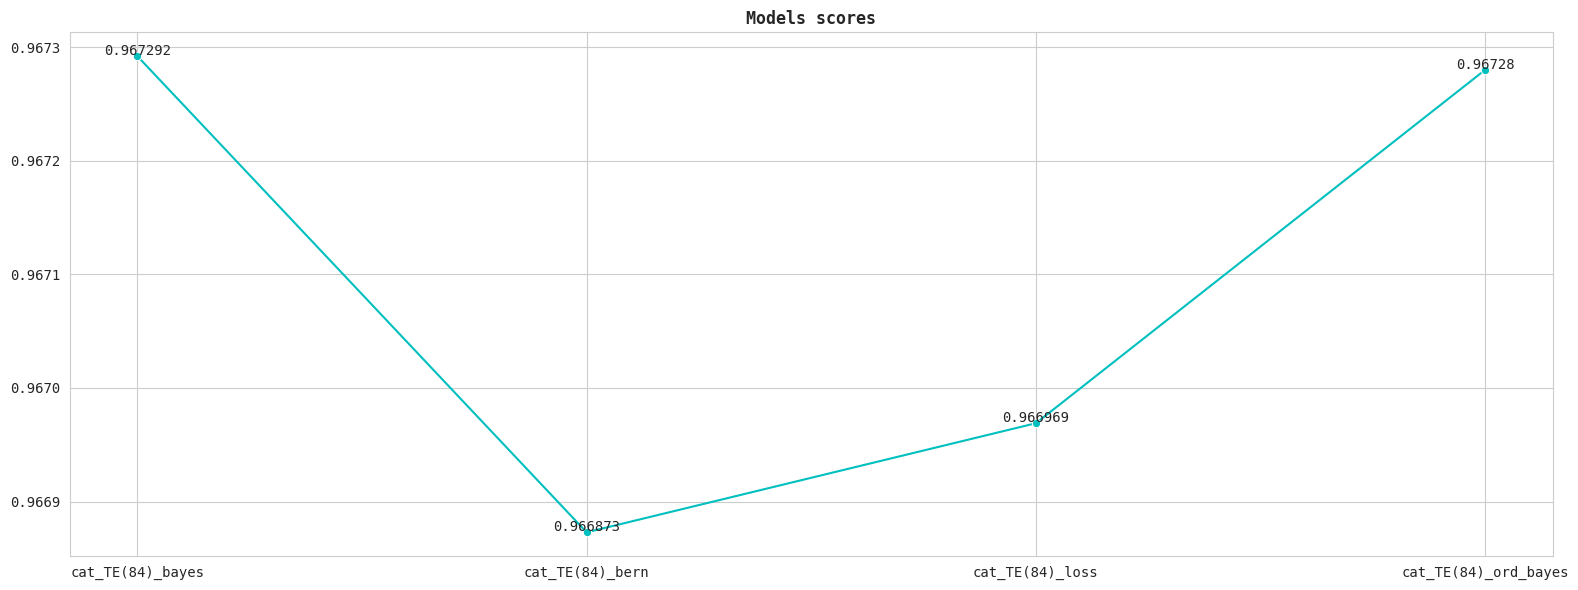

In [40]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

plt.tight_layout()
plt.show()

cat_TE(84)_bayes_967292 saved!


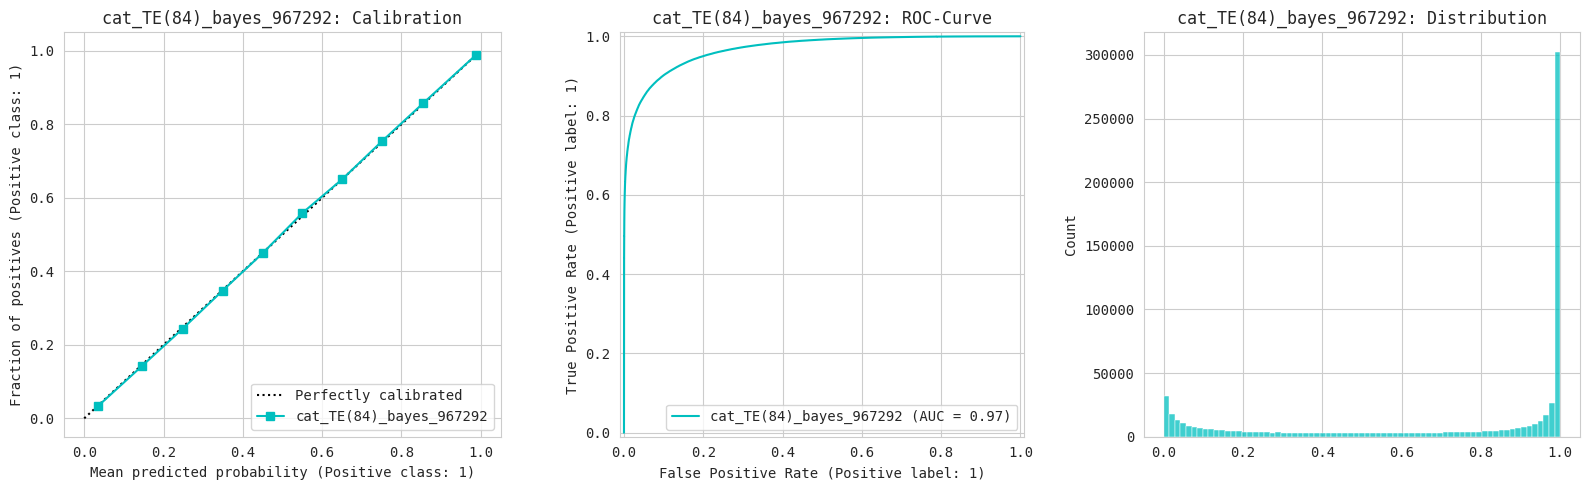


cat_TE(84)_bern_966873 saved!


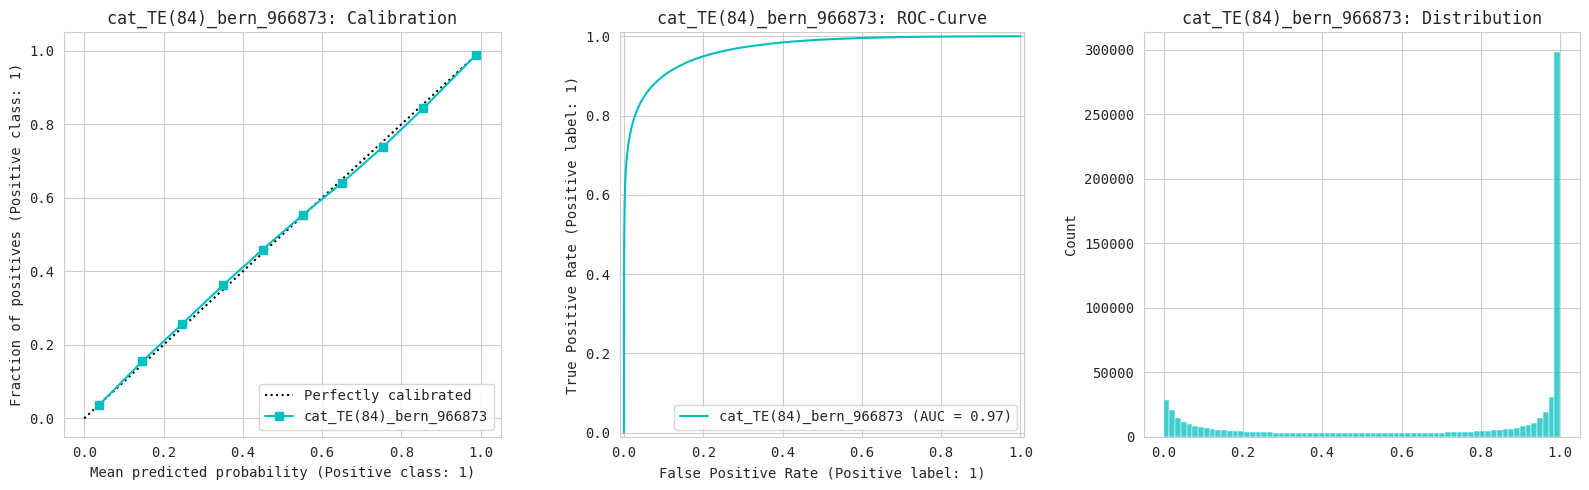


cat_TE(84)_loss_966969 saved!


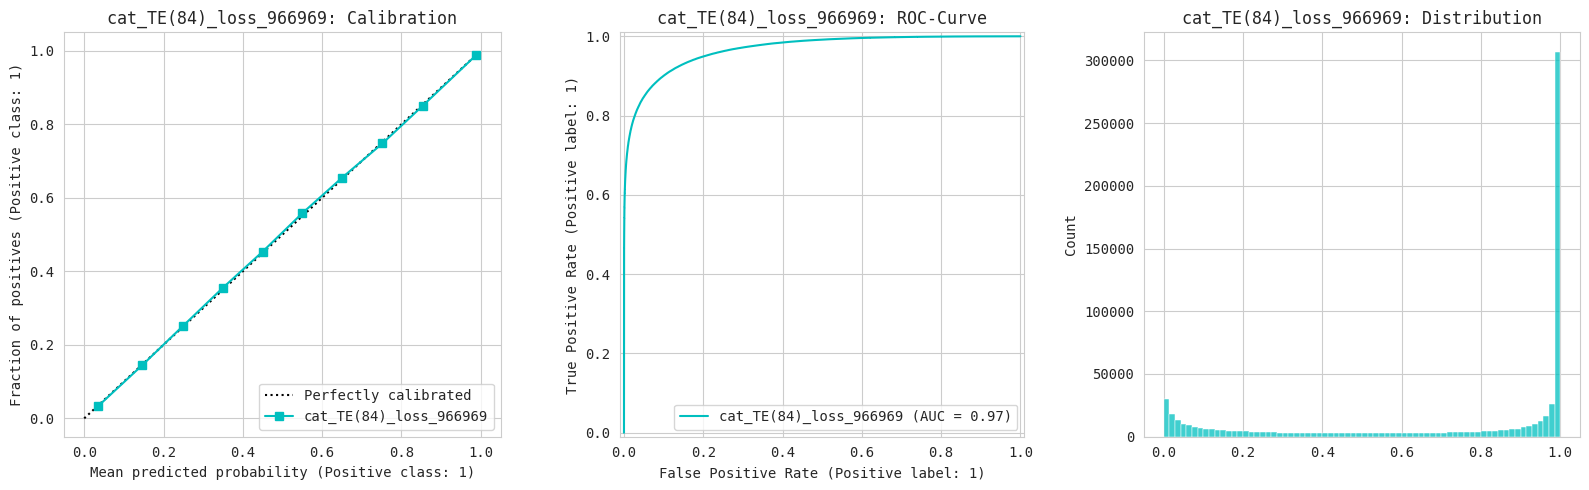


cat_TE(84)_ord_bayes_96728 saved!


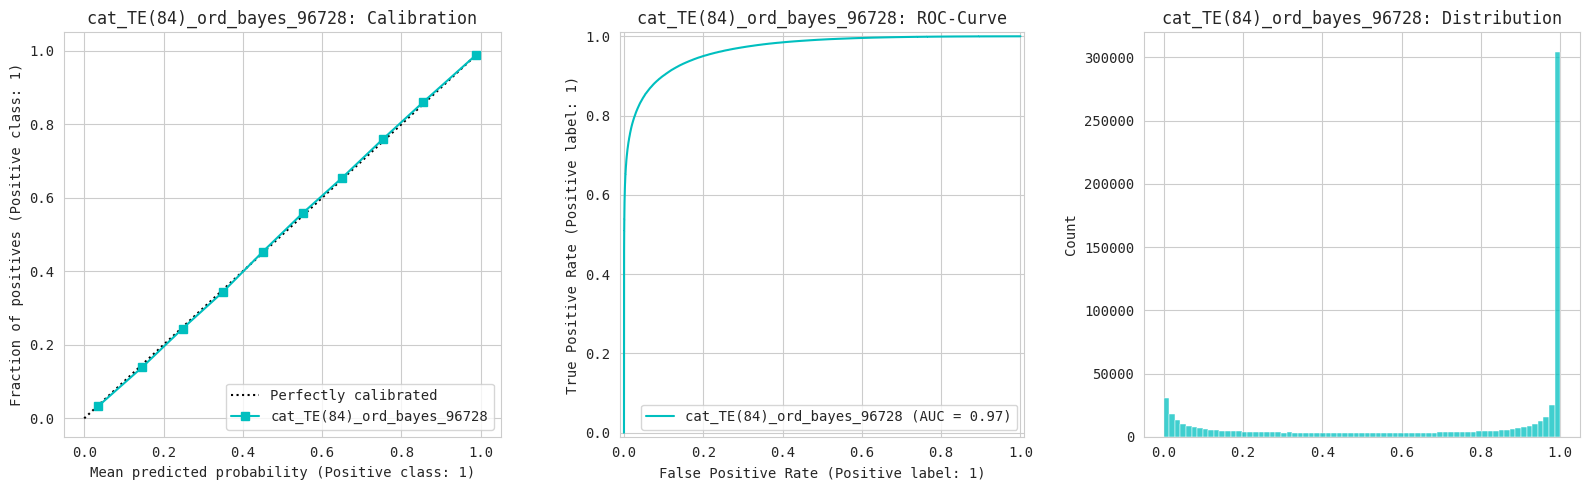

In [41]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [42]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

cat_TE(84)_bayes_967292 saved! (296302,)
cat_TE(84)_bern_966873 saved! (296302,)
cat_TE(84)_loss_966969 saved! (296302,)
cat_TE(84)_ord_bayes_96728 saved! (296302,)


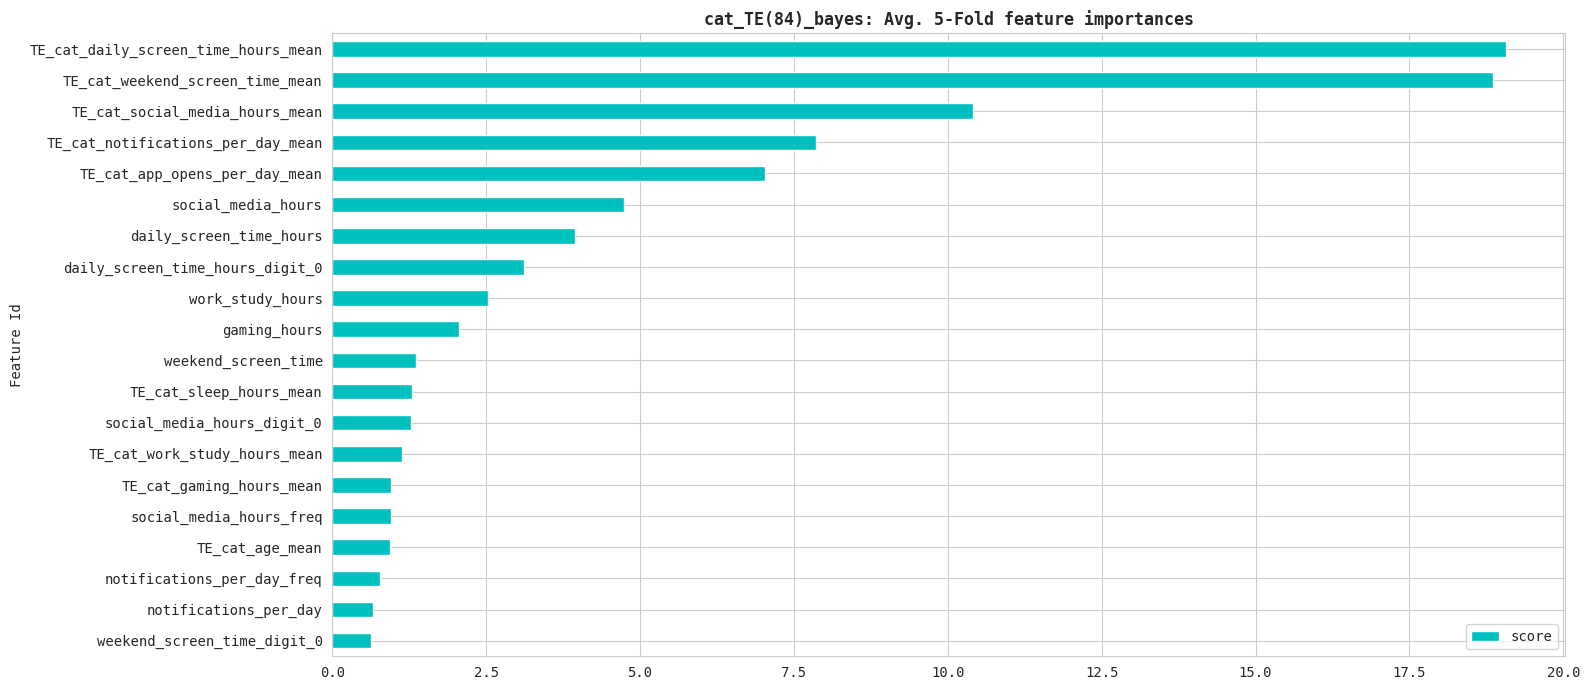

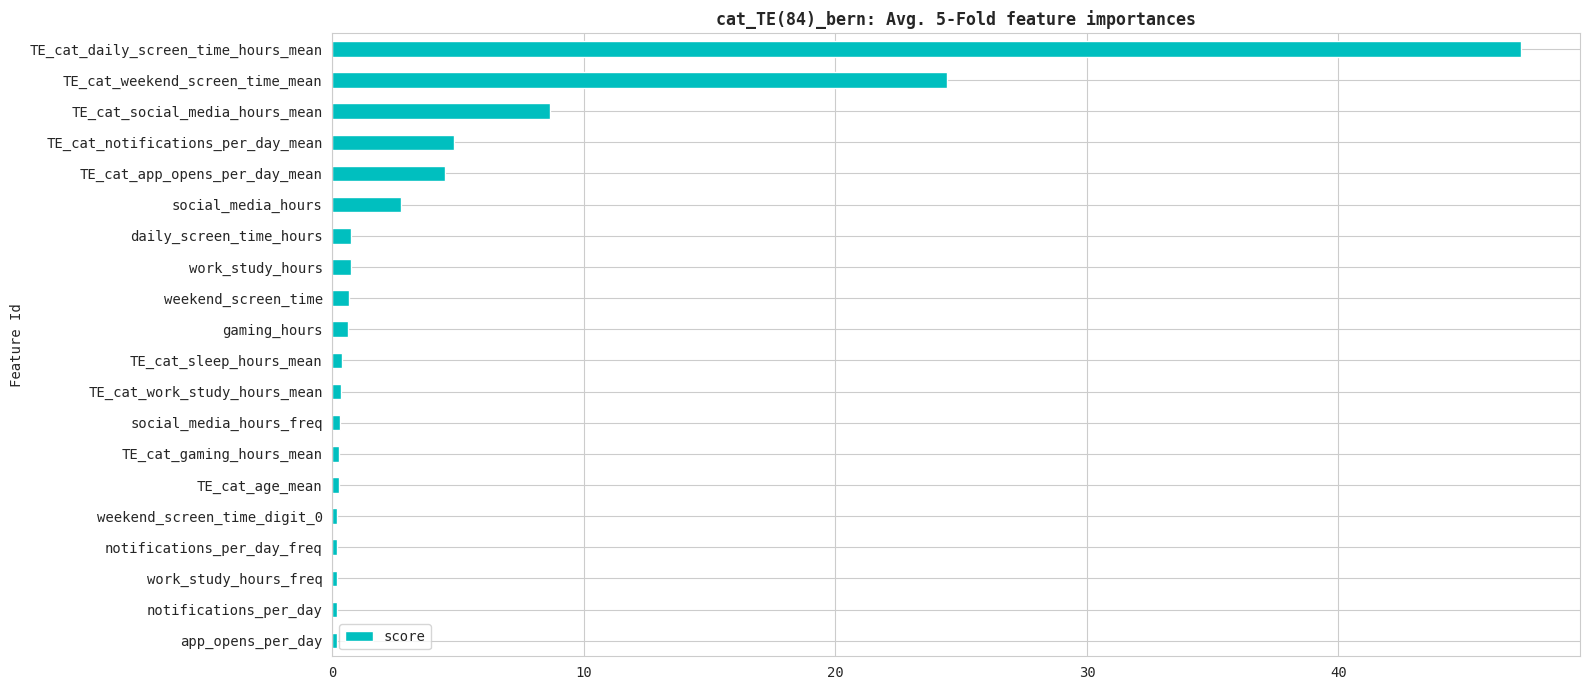

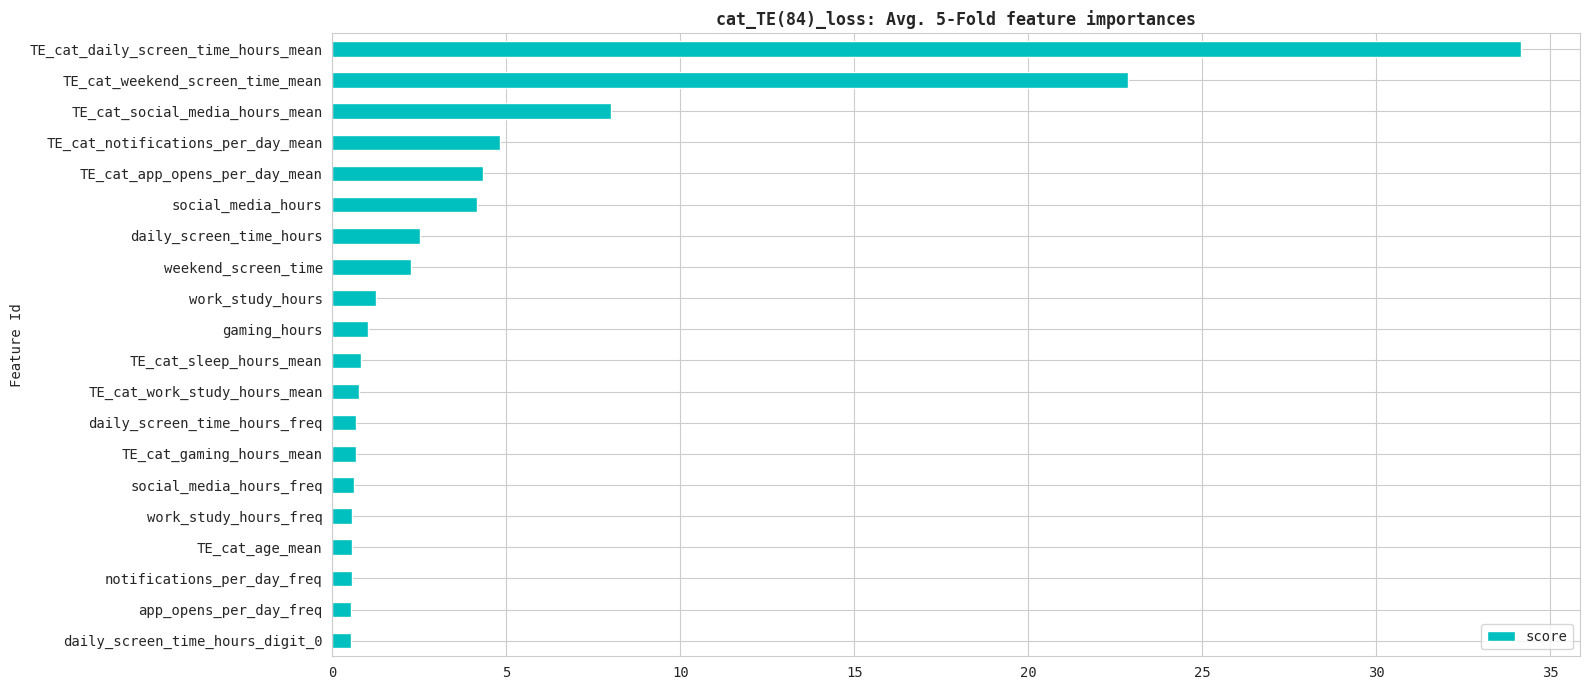

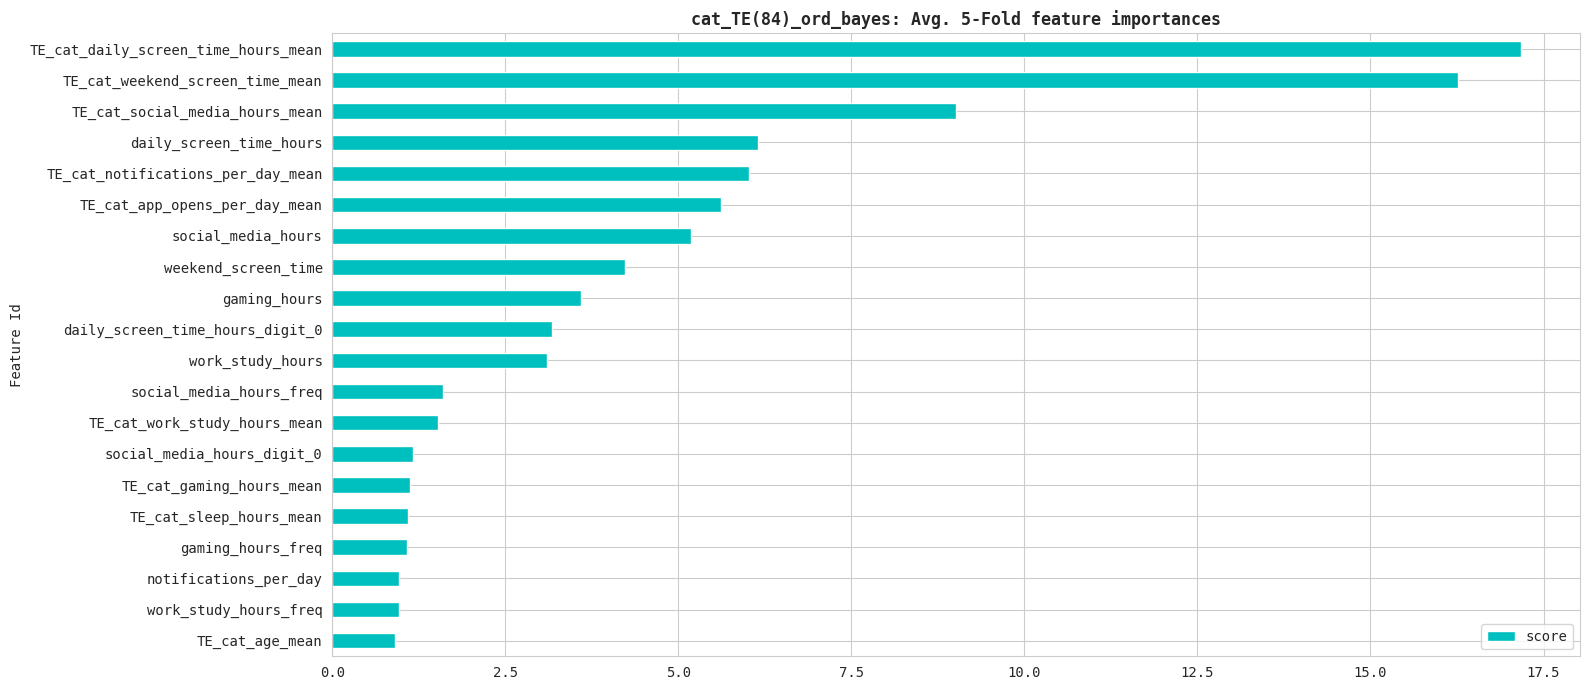

In [43]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_feat_importances[k] = y # np.mean(value, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

top_n = 20

for i, (m, df) in enumerate(all_feat_importances.items()):
    df_merge = df[0].merge(df[1], how="left", on="Feature Id", suffixes=("_0", ""))\
                    .merge(df[2], how="left", on="Feature Id", suffixes=("_1", ""))\
                    .merge(df[3], how="left", on="Feature Id", suffixes=("_2", ""))\
                    .merge(df[4], how="left", on="Feature Id", suffixes=("_3", "_4"))

    # display(df_merge.head())
    ## -------------------------------------------------------------------------------
    # df_merge["avg_score"] = df_merge.iloc[:, 1:].mean(axis=1)
    # df_merge.sort_values(by="avg_score").iloc[:, :top_n].plot.barh(y="avg_score", x="Feature Id", figsize=(18, 8))
    # plt.tight_layout()
    # plt.show()
    # print()
    ## -------------------------------------------------------------------------------
    df_final = pd.concat([df[0]["Feature Id"], df_merge.drop(columns=["Feature Id"])\
                                                       .mean(axis=1)], axis=1)\
                                                       .rename(columns={0: "score"})\
                                                       .sort_values(by="score")

    ax = df_final.tail(top_n).plot.barh(y="score", x="Feature Id", figsize=(16, 7))
    ax.set_title(f"{m}: Avg. {CFG['FOLDS']}-Fold feature importances", fontweight="semibold")
    plt.tight_layout()
    plt.show()
    print()

In [44]:
pd.DataFrame(model_results)

,cat_TE(84)_bayes_967292,cat_TE(84)_bern_966873,cat_TE(84)_loss_966969,cat_TE(84)_ord_bayes_96728
0,0.999637,0.999704,0.999616,0.999825
1,0.966193,0.963080,0.962690,0.962060
2,0.856206,0.862365,0.850650,0.859309
3,0.996802,0.993104,0.997114,0.996134
4,0.998739,0.996415,0.997899,0.998419
...,...,...,...,...
296297,0.999999,0.999981,1.000000,1.000000
296298,0.632055,0.566402,0.502473,0.612369
296299,0.154672,0.139439,0.170411,0.152482
296300,0.761372,0.766033,0.808551,0.782052


In [45]:
# !rm -r /kaggle/working